# HepaGuard — Step 2: Train + Evaluate (Local)

This notebook:
- loads `data/processed/hepaguard_features_with_usfli.parquet`
- trains core + enhanced models (LogReg, RF, XGBoost)
- tunes threshold to hit Recall ≥ 0.85 on validation
- evaluates on test with AUROC, PR-AUC, Recall, Precision, F1, Confusion Matrix, Calibration
- runs SHAP on XGBoost to pick top N features and retrain
- saves artifacts under `models/` and reports under `reports/`


In [47]:
import os
from pathlib import Path
import json
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, brier_score_loss
)
from sklearn.calibration import calibration_curve

import xgboost as xgb
import shap


In [48]:
DATA_PATH = Path("../data/processed/hepaguard_features_with_usfli.parquet")
RANDOM_SEED = 42

ID_COL = "SEQN"
LABEL_COL = "masld_usfli_label"

CORE_FEATURES = [
    "age_years","sex_code","bmi","waist_cm","alt_u_l","ast_u_l",
    "platelets_1000cells_ul","hdl_mg_dl","alcohol_drinks_per_day","sedentary_min_per_day"
]
ENH_FEATURES = CORE_FEATURES + ["fasting_glucose_mg_dl","triglycerides_mg_dl"]

N_TOP = 12  # for SHAP feature selection
MIN_RECALL = 0.85


In [49]:

df = pd.read_parquet(DATA_PATH)
print("Total rows:", len(df))

labeled = df[df[LABEL_COL].notna()].copy()
labeled[LABEL_COL] = labeled[LABEL_COL].astype(int)

print("Labeled rows:", len(labeled))
print("Positive rate:", labeled[LABEL_COL].mean())
labeled.head()


Total rows: 9693
Labeled rows: 3892
Positive rate: 0.3725590955806783


,SEQN,age_years,sex_code,bmi,waist_cm,alt_u_l,ast_u_l,platelets_1000cells_ul,triglycerides_mg_dl,hdl_mg_dl,fasting_glucose_mg_dl,alcohol_drinks_per_day,sedentary_min_per_day,usfli_score,masld_usfli_label
3,109271.0,49.0,1.0,29.7,120.4,8.0,14.0,254.0,84.0,33.0,103.0,0.0,60.0,37.095076,1
5,109274.0,68.0,1.0,30.2,109.6,19.0,20.0,173.0,133.0,29.0,154.0,2.0,300.0,40.631884,1
10,109290.0,68.0,2.0,28.1,92.0,19.0,18.0,289.0,102.0,40.0,106.0,0.0,180.0,25.548713,0
12,109292.0,58.0,1.0,30.5,108.3,21.0,18.0,196.0,90.0,52.0,181.0,6.0,600.0,65.333451,1
15,109297.0,30.0,2.0,23.2,73.2,17.0,14.0,316.0,44.0,82.0,92.0,2.0,600.0,13.141021,0


In [50]:
train_df, temp_df = train_test_split(
    labeled, test_size=0.30, random_state=RANDOM_SEED, stratify=labeled[LABEL_COL]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=RANDOM_SEED, stratify=temp_df[LABEL_COL]
)

print("Train/Val/Test:", len(train_df), len(val_df), len(test_df))
print("Train pos rate:", train_df[LABEL_COL].mean())
print("Val pos rate:", val_df[LABEL_COL].mean())
print("Test pos rate:", test_df[LABEL_COL].mean())


Train/Val/Test: 2724 584 584
Train pos rate: 0.37261380323054333
Val pos rate: 0.3732876712328767
Test pos rate: 0.3715753424657534


In [51]:
def build_xy(df, feature_cols):
    X = df[feature_cols].copy()
    y = df[LABEL_COL].values
    return X, y

def summarize_metrics(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "auroc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "recall": recall_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred),
        "brier": brier_score_loss(y_true, y_proba),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
        "threshold": float(threshold),
    }

def tune_threshold_for_min_recall(y_true, y_proba, min_recall=0.90):
    # scan thresholds from 0..1; pick highest F1 among those meeting recall constraint
    thresholds = np.linspace(0, 1, 501)
    best = None
    rows = []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        rec = recall_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        rows.append((t, rec, prec, f1))
        if rec >= min_recall:
            if best is None or f1 > best[3]:
                best = (t, rec, prec, f1)
    table = pd.DataFrame(rows, columns=["threshold","recall","precision","f1"])
    if best is None:
        # fallback: maximize recall (even if below min_recall)
        best_row = table.sort_values(["recall","f1"], ascending=False).iloc[0]
        return float(best_row["threshold"]), table
    return float(best[0]), table


In [52]:
def train_and_eval(feature_cols, model_name_prefix):
    X_train, y_train = build_xy(train_df, feature_cols)
    X_val, y_val = build_xy(val_df, feature_cols)
    X_test, y_test = build_xy(test_df, feature_cols)

    # shared imputer (+ missing indicators)
    imputer = SimpleImputer(strategy="median", add_indicator=True)

    # --- Logistic Regression baseline (with scaling) ---
    logreg = Pipeline([
        ("imputer", imputer),
        ("scaler", StandardScaler(with_mean=False)),  # sparse-safe due to indicators
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
    ])
    logreg.fit(X_train, y_train)
    val_proba_lr = logreg.predict_proba(X_val)[:, 1]
    thr_lr, _ = tune_threshold_for_min_recall(y_val, val_proba_lr, MIN_RECALL)
    test_proba_lr = logreg.predict_proba(X_test)[:, 1]
    lr_metrics = summarize_metrics(y_test, test_proba_lr, thr_lr)

    # --- Random Forest baseline ---
    rf = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("clf", RandomForestClassifier(
            n_estimators=500,
            random_state=RANDOM_SEED,
            class_weight="balanced_subsample",
            n_jobs=-1
        ))
    ])
    rf.fit(X_train, y_train)
    val_proba_rf = rf.predict_proba(X_val)[:, 1]
    thr_rf, _ = tune_threshold_for_min_recall(y_val, val_proba_rf, MIN_RECALL)
    test_proba_rf = rf.predict_proba(X_test)[:, 1]
    rf_metrics = summarize_metrics(y_test, test_proba_rf, thr_rf)

    # --- XGBoost production ---
    # Compute scale_pos_weight from training labels
    pos = (y_train == 1).sum()
    neg = (y_train == 0).sum()
    spw = (neg / pos) if pos > 0 else 1.0

    xgb_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("clf", xgb.XGBClassifier(
            n_estimators=800,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            min_child_weight=1.0,
            gamma=0.0,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=spw,
            random_state=RANDOM_SEED,
            n_jobs=-1,
        ))
    ])

    xgb_model.fit(X_train, y_train)
    val_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]
    thr_xgb, thr_table = tune_threshold_for_min_recall(y_val, val_proba_xgb, MIN_RECALL)
    test_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
    xgb_metrics = summarize_metrics(y_test, test_proba_xgb, thr_xgb)

    results = {
        "feature_set": model_name_prefix,
        "n_train": int(len(train_df)),
        "n_val": int(len(val_df)),
        "n_test": int(len(test_df)),
        "logreg": lr_metrics,
        "rf": rf_metrics,
        "xgb": xgb_metrics,
        "xgb_threshold_table": thr_table
    }
    return results, xgb_model, (X_train, y_train, X_val, y_val, X_test, y_test)


In [53]:
core_results, core_xgb, core_data = train_and_eval(CORE_FEATURES, "core")
enh_results, enh_xgb, enh_data = train_and_eval(ENH_FEATURES, "enhanced")

core_results["xgb"]

{'auroc': 0.8871909491580758,
 'pr_auc': 0.8195250781635149,
 'recall': 0.847926267281106,
 'precision': 0.696969696969697,
 'f1': 0.7650727650727651,
 'brier': 0.13500908017158508,
 'confusion_matrix': [[287, 80], [33, 184]],
 'threshold': 0.31}

In [54]:
def quick_table(res):
    rows = []
    for k in ["logreg","rf","xgb"]:
        m = res[k]
        rows.append([k, m["auroc"], m["pr_auc"], m["recall"], m["precision"], m["f1"], m["brier"], m["threshold"]])
    return pd.DataFrame(rows, columns=["model","AUROC","PR-AUC","Recall","Precision","F1","Brier","Threshold"])

print("CORE:")
display(quick_table(core_results))

print("\nENHANCED:")
display(quick_table(enh_results))


CORE:


,model,AUROC,PR-AUC,Recall,Precision,F1,Brier,Threshold
0,logreg,0.888032,0.823770,0.811060,0.687500,0.744186,0.133663,0.474
1,rf,0.898385,0.851936,0.824885,0.699219,0.756871,0.124238,0.344
2,xgb,0.887191,0.819525,0.847926,0.696970,0.765073,0.135009,0.310



ENHANCED:


,model,AUROC,PR-AUC,Recall,Precision,F1,Brier,Threshold
0,logreg,0.905210,0.851996,0.838710,0.713725,0.771186,0.121006,0.446
1,rf,0.918319,0.879326,0.875576,0.695971,0.775510,0.112069,0.286
2,xgb,0.921194,0.885340,0.834101,0.744856,0.786957,0.112258,0.344


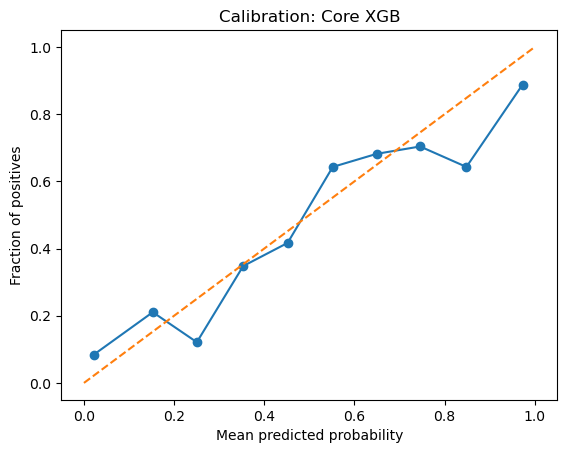

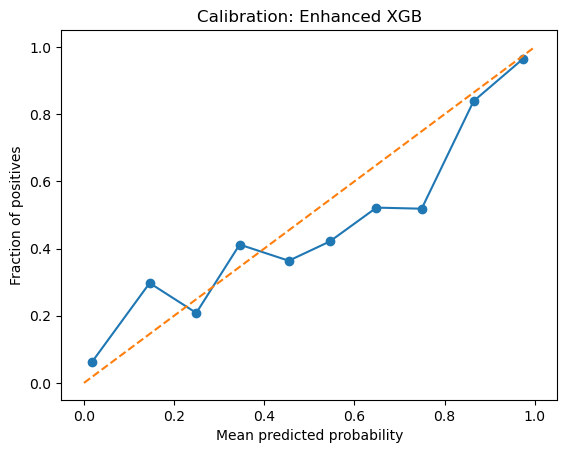

In [55]:
import matplotlib.pyplot as plt

def plot_calibration(y_true, y_prob, title):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy="uniform")
    plt.figure()
    plt.plot(prob_pred, prob_true, marker="o")
    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(title)
    plt.show()

# Core XGB calibration
_, _, _, _, X_test_core, y_test_core = core_data
core_test_proba = core_xgb.predict_proba(X_test_core)[:,1]
plot_calibration(y_test_core, core_test_proba, "Calibration: Core XGB")

# Enhanced XGB calibration
_, _, _, _, X_test_enh, y_test_enh = enh_data
enh_test_proba = enh_xgb.predict_proba(X_test_enh)[:,1]
plot_calibration(y_test_enh, enh_test_proba, "Calibration: Enhanced XGB")


In [56]:
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
import scipy.sparse as sp

def shap_importance_for_pipeline(pipeline, X_sample, base_feature_cols):
    # Pull fitted pieces
    imputer = pipeline.named_steps["imputer"]
    clf = pipeline.named_steps["clf"]  # XGBClassifier

    # Transform using the *fitted* imputer (do NOT fit_transform)
    Xt = imputer.transform(X_sample)

    # Make it a plain dense float32 array (SHAP/XGB are happiest here)
    if sp.issparse(Xt):
        Xt = Xt.toarray()
    Xt = np.asarray(Xt, dtype=np.float32)

    # Build feature names: base + missing indicators
    ind_features = []
    indicator = getattr(imputer, "indicator_", None)
    if indicator is not None and getattr(indicator, "features_", None) is not None:
        ind_features = [f"{base_feature_cols[i]}_missing" for i in indicator.features_]
    feature_names = list(base_feature_cols) + ind_features

    # Use the underlying Booster for SHAP
    booster = clf.get_booster()

    # SHAP with Booster + disable additivity check
    explainer = shap.TreeExplainer(booster)
    shap_vals = explainer.shap_values(Xt, check_additivity=False)

    # XGBoost pred_contribs returns (n, m+1) with bias as last column
    shap_vals = np.asarray(shap_vals)
    if shap_vals.ndim == 2 and shap_vals.shape[1] == (len(feature_names) + 1):
        shap_vals = shap_vals[:, :-1]

    mean_abs = np.abs(shap_vals).mean(axis=0)
    imp = (
        pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs})
        .sort_values("mean_abs_shap", ascending=False)
    )
    return imp


In [57]:
X_train_core, y_train_core, *_ = core_data
core_sample = X_train_core.sample(n=min(1000, len(X_train_core)), random_state=RANDOM_SEED)
core_imp = shap_importance_for_pipeline(core_xgb, core_sample, CORE_FEATURES)
core_imp.head(20)

,feature,mean_abs_shap
4,alt_u_l,1.442187
3,waist_cm,1.376726
0,age_years,0.830628
2,bmi,0.734799
7,hdl_mg_dl,0.578235
5,ast_u_l,0.514866
6,platelets_1000cells_ul,0.329583
1,sex_code,0.234947
9,sedentary_min_per_day,0.221214
8,alcohol_drinks_per_day,0.137011


In [58]:
def retrain_xgb_on_top_features(base_feature_cols, top_features, model_name):
    # keep only base features (ignore *_missing features in selection for simplicity)
    selected_base = [f for f in top_features if (f in base_feature_cols)]
    if len(selected_base) < 5:
        raise ValueError("Too few base features selected; check SHAP output.")

    res, model, data = train_and_eval(selected_base, f"{model_name}_top{len(selected_base)}")
    return selected_base, res, model, data

top_core = core_imp["feature"].head(N_TOP).tolist()
selected_core_base, core_top_res, core_top_xgb, _ = retrain_xgb_on_top_features(CORE_FEATURES, top_core, "core")

print("Selected core base features:", selected_core_base)
display(quick_table(core_results))
display(quick_table(core_top_res))


Selected core base features: ['alt_u_l', 'waist_cm', 'age_years', 'bmi', 'hdl_mg_dl', 'ast_u_l', 'platelets_1000cells_ul', 'sex_code', 'sedentary_min_per_day', 'alcohol_drinks_per_day']


,model,AUROC,PR-AUC,Recall,Precision,F1,Brier,Threshold
0,logreg,0.888032,0.823770,0.811060,0.687500,0.744186,0.133663,0.474
1,rf,0.898385,0.851936,0.824885,0.699219,0.756871,0.124238,0.344
2,xgb,0.887191,0.819525,0.847926,0.696970,0.765073,0.135009,0.310


,model,AUROC,PR-AUC,Recall,Precision,F1,Brier,Threshold
0,logreg,0.888032,0.823770,0.811060,0.68750,0.744186,0.133663,0.474
1,rf,0.897619,0.850246,0.852535,0.67029,0.750507,0.124246,0.312
2,xgb,0.887191,0.821433,0.852535,0.67029,0.750507,0.135879,0.288


In [59]:
out = {
    "core": {k: v for k, v in core_results.items() if k != "xgb_threshold_table"},
    "enhanced": {k: v for k, v in enh_results.items() if k != "xgb_threshold_table"},
    "core_shap_top": core_imp.head(30).to_dict(orient="records"),
}

Path("reports").mkdir(exist_ok=True)
with open("reports/notebook_summary.json", "w") as f:
    json.dump(out, f, indent=2)

print("Wrote reports/notebook_summary.json")


Wrote reports/notebook_summary.json
